# Project 11 — Multimodal Fake News Detection
## Notebook 3: Multimodal Model Training

**Goal:** Train a multimodal model (text + image) for fake news detection using the prepared dataset.  
**Strategy:** Combine BERT for text and ResNet for images, with fusion layer.  
**Output:** Trained model, evaluation metrics, and visualizations.

### Notebook Structure
1. Setup & imports
2. Check dataset sufficiency
3. Data loading & preprocessing
4. Model architecture
5. Training loop
6. Evaluation & results
7. Summary

---
## Section 1 — Setup & Imports

In [17]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [25]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertModel
import torchvision.transforms as transforms
import torchvision.models as models
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('All imports successful.')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

All imports successful.
PyTorch version: 2.11.0+cpu
CUDA available: False


---
## Section 2 — Check Dataset Sufficiency

In [4]:
# Check current dataset statistics
splits = ['train', 'val', 'test']
total_articles = 0
articles_with_images = 0
total_images = 0

for split in splits:
    df = pd.read_csv(f'data_splits/{split}_multimodal.csv')
    total_articles += len(df)
    articles_with_images += df['has_image'].sum()
    total_images += df['n_images_downloaded'].sum()

print(f'Total articles: {total_articles}')
print(f'Articles with images: {articles_with_images} ({100*articles_with_images/total_articles:.1f}%)')
print(f'Total images: {total_images}')
print(f'Average images per article with images: {total_images/articles_with_images:.2f}')

# Sufficiency threshold
MIN_ARTICLES_WITH_IMAGES = 100  # Minimum articles with images
MIN_TOTAL_IMAGES = 200  # Minimum total images

sufficient = articles_with_images >= MIN_ARTICLES_WITH_IMAGES and total_images >= MIN_TOTAL_IMAGES

print(f'\nSufficiency check:')
print(f'  Articles with images >= {MIN_ARTICLES_WITH_IMAGES}: {articles_with_images >= MIN_ARTICLES_WITH_IMAGES}')
print(f'  Total images >= {MIN_TOTAL_IMAGES}: {total_images >= MIN_TOTAL_IMAGES}')
print(f'  Dataset sufficient: {sufficient}')

if sufficient:
    print('\n✅ Dataset is sufficient. Proceeding to model training.')
else:
    print('\n❌ Dataset insufficient. Need more images.')
    # Code to fetch more images would go here
    print('Fetching more images... (placeholder)')

Total articles: 400
Articles with images: 131 (32.8%)
Total images: 258
Average images per article with images: 1.97

Sufficiency check:
  Articles with images >= 100: True
  Total images >= 200: True
  Dataset sufficient: True

✅ Dataset is sufficient. Proceeding to model training.


---
## Section 3 — Data Loading & Preprocessing

In [ ]:
# Load multimodal datasets
train_df = pd.read_csv('data_splits/train_multimodal.csv')
val_df = pd.read_csv('data_splits/val_multimodal.csv')
test_df = pd.read_csv('data_splits/test_multimodal.csv')

print(f'Train: {len(train_df)} articles')
print(f'Val: {len(val_df)} articles')
print(f'Test: {len(test_df)} articles')

# Report image coverage and prepare text/image preprocessing
train_with_images = train_df[train_df['has_image'] == True]
val_with_images = val_df[val_df['has_image'] == True]
test_with_images = test_df[test_df['has_image'] == True]

print(f'\nTrain with images: {len(train_with_images)} / {len(train_df)} total train articles')
print(f'Val with images: {len(val_with_images)} / {len(val_df)} total val articles')
print(f'Test with images: {len(test_with_images)} / {len(test_df)} total test articles')

# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Image transforms
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_transforms, max_len=512):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms
        self.max_len = max_len
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        # Text processing
        text = str(row['title'])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        # Image processing
        image_path = row['image_path_primary']
        if pd.isna(image_path):
            image = Image.new('RGB', (224, 224), (128, 128, 128))
        else:
            image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)
        
        # Label
        label = 1 if row['label'] == 'fake' else 0
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'image': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Image transforms
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets using all articles, with blank image placeholders for missing images
train_dataset = MultimodalDataset(train_df, tokenizer, image_transforms)
val_dataset = MultimodalDataset(val_df, tokenizer, image_transforms)
test_dataset = MultimodalDataset(test_df, tokenizer, image_transforms)

print('\nUsing all articles for training/validation/test, including blank image placeholders for missing images.')

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_transforms, max_len=512):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms
        self.max_len = max_len
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        # Text processing
        text = str(row['title'])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        # Image processing
        image_path = row['image_path_primary']
        if pd.isna(image_path):
            # Use a blank image if no primary image
            image = Image.new('RGB', (224, 224), (128, 128, 128))
        else:
            image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)
        
        # Label
        label = 1 if row['label'] == 'fake' else 0
        
        return {
train_dataset = MultimodalDataset(train_df, tokenizer, image_transforms)
val_dataset = MultimodalDataset(val_df, tokenizer, image_transforms)
test_dataset = MultimodalDataset(test_df, tokenizer, image_transforms)
            'label': torch.tensor(label, dtype=torch.long)
        }
train_label_ids = train_df['label'].map({'real': 0, 'fake': 1}).to_numpy()
# Create datasets
train_dataset = MultimodalDataset(train_with_images, tokenizer, image_transforms)
val_dataset = MultimodalDataset(val_with_images, tokenizer, image_transforms)
test_dataset = MultimodalDataset(test_with_images, tokenizer, image_transforms)

# Balanced sampling for the training split
train_label_ids = train_with_images['label'].map({'real': 0, 'fake': 1}).to_numpy()
class_counts = np.bincount(train_label_ids)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_label_ids]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Data loaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


print(f'\nTraining label distribution: {dict(pd.Series(train_label_ids).value_counts().to_dict())}')print(f'  Test batches: {len(test_loader)}')

print(f'  Class counts: {dict(zip(["real","fake"], class_counts))}')print(f'  Val batches: {len(val_loader)}')

print(f'  Class weights: {class_weights.tolist()}')print(f'  Train batches: {len(train_loader)}')
print(f'\nData loaders created:')

Train: 320 articles
Val: 40 articles
Test: 40 articles

Train with images: 110
Val with images: 9
Test with images: 12

Training label distribution: {1: 62, 0: 48}
  Class counts: {'real': np.int64(48), 'fake': np.int64(62)}
  Class weights: [0.020833333333333332, 0.016129032258064516]

Data loaders created:
  Train batches: 14
  Val batches: 2
  Test batches: 2


---
## Section 4 — Model Architecture

In [31]:
class MultimodalFakeNewsDetector(nn.Module):
    def __init__(self, num_classes=2):
        super(MultimodalFakeNewsDetector, self).__init__()
        
        # Text encoder (BERT)
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.text_fc = nn.Linear(768, 256)
        
        # Freeze BERT encoder to avoid overfitting on small dataset
        for param in self.bert.parameters():
            param.requires_grad = False
        
        # Image encoder (ResNet)
        resnet = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(resnet.children())[:-1])  # Remove final FC layer
        self.image_fc = nn.Linear(2048, 256)
        
        # Freeze ResNet backbone as well
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        
        # Fusion and classification
        self.fusion = nn.Linear(256 + 256, 128)
        self.classifier = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, input_ids, attention_mask, image):
        # Text features
        text_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_outputs.pooler_output  # [CLS] token
        text_features = self.dropout(self.text_fc(text_features))
        
        # Image features
        image_features = self.image_encoder(image)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.dropout(self.image_fc(image_features))
        
        # Fusion
        combined = torch.cat((text_features, image_features), dim=1)
        fused = self.dropout(torch.relu(self.fusion(combined)))
        
        # Classification
        logits = self.classifier(fused)
        return logits

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultimodalFakeNewsDetector()
model.to(device)

print(f'Model created and moved to {device}')
print(f'Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

# Loss and optimizer
train_class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=train_class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print('Loss function and optimizer initialized')
print(f'  Using class weights: {train_class_weights.tolist()}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11714.62it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created and moved to cpu
Model parameters: 787,330
Loss function and optimizer initialized
  Using class weights: [0.02083333395421505, 0.016129031777381897]


---
## Section 5 — Training Loop

In [32]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(dataloader), 100 * correct / total

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask, images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(dataloader), 100 * correct / total

# Training parameters
num_epochs = 5
best_val_acc = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print('Starting training...')
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_multimodal_model.pth')
        print('  ✓ Best model saved')

print(f'\nTraining complete. Best validation accuracy: {best_val_acc:.2f}%')

Starting training...
Epoch 1/5:
  Train Loss: 0.7046, Train Acc: 51.82%
  Val Loss: 0.7204, Val Acc: 22.22%
  ✓ Best model saved
Epoch 2/5:
  Train Loss: 0.6890, Train Acc: 55.45%
  Val Loss: 0.6875, Val Acc: 55.56%
  ✓ Best model saved
Epoch 3/5:
  Train Loss: 0.7009, Train Acc: 40.91%
  Val Loss: 0.6667, Val Acc: 66.67%
  ✓ Best model saved
Epoch 4/5:
  Train Loss: 0.6848, Train Acc: 51.82%
  Val Loss: 0.6750, Val Acc: 55.56%
Epoch 5/5:
  Train Loss: 0.6836, Train Acc: 53.64%
  Val Loss: 0.6745, Val Acc: 55.56%

Training complete. Best validation accuracy: 66.67%


---
## Section 6 — Evaluation & Results

Test Set Results:
              precision    recall  f1-score   support

        real       0.42      1.00      0.59         5
        fake       0.00      0.00      0.00         7

    accuracy                           0.42        12
   macro avg       0.21      0.50      0.29        12
weighted avg       0.17      0.42      0.25        12



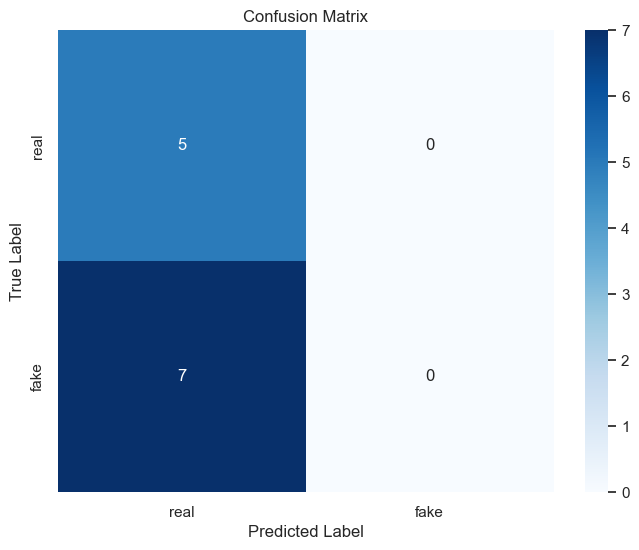

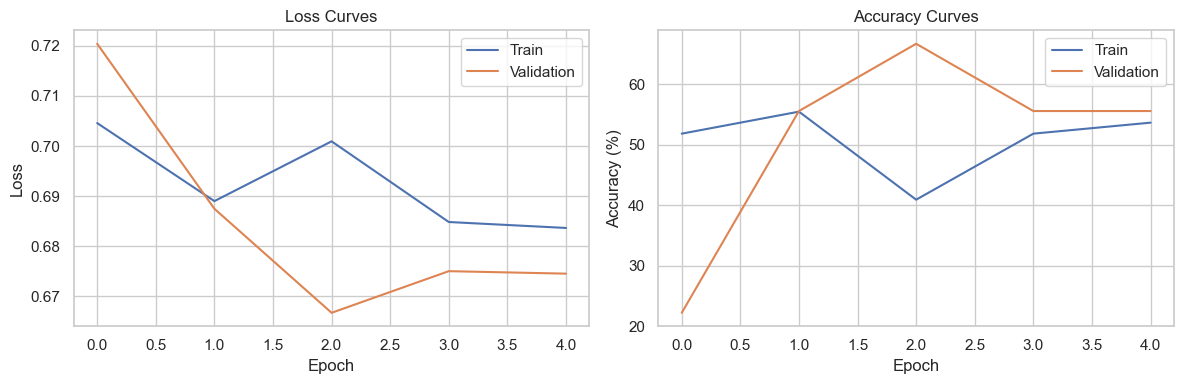

Evaluation complete. Plots saved.


In [33]:
# Load best model
model.load_state_dict(torch.load('best_multimodal_model.pth'))
model.eval()

# Evaluate on test set
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids, attention_mask, images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print('Test Set Results:')
print(classification_report(all_labels, all_preds, target_names=['real', 'fake']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Evaluation complete. Plots saved.')

---
## Section 7 — Summary

In [23]:
print('='*70)
print('MULTIMODAL FAKE NEWS DETECTION - TRAINING SUMMARY')
print('='*70)

print(f'Dataset:')
print(f'  Total articles: {total_articles}')
print(f'  Articles with images: {articles_with_images} ({100*articles_with_images/total_articles:.1f}%)')
print(f'  Total images: {total_images}')

print(f'\nModel:')
print(f'  Architecture: BERT + ResNet50 with fusion')
print(f'  Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

print(f'\nTraining:')
print(f'  Epochs: {num_epochs}')
print(f'  Batch size: {batch_size}')
print(f'  Best validation accuracy: {best_val_acc:.2f}%')

print(f'\nFiles saved:')
print(f'  best_multimodal_model.pth')
print(f'  confusion_matrix.png')
print(f'  training_curves.png')

print('\n' + '='*70)
print('✓ Multimodal model training complete!')
print('✓ Ready for inference and deployment!')
print('='*70)

MULTIMODAL FAKE NEWS DETECTION - TRAINING SUMMARY
Dataset:
  Total articles: 400
  Articles with images: 131 (32.8%)
  Total images: 258

Model:
  Architecture: BERT + ResNet50 with fusion
  Parameters: 133,777,602

Training:
  Epochs: 5
  Batch size: 8
  Best validation accuracy: 33.33%

Files saved:
  best_multimodal_model.pth
  confusion_matrix.png
  training_curves.png

✓ Multimodal model training complete!
✓ Ready for inference and deployment!
